<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação do sklearn.

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:
- correto
- reprodutível
- bem estruturado
- criticamente analisado

# Dicas importantes

## Sobre o dataset (Fashion MNIST)

- Utilize `fetch_openml` do sklearn para carregar os dados
- Use: `as_frame=False`
- Use: `mnist_784`
- Converta os rótulos para inteiro:
  
  ```python
  y = y.astype(int)
  ```

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST`
Realize a separação em treino e teste
Utilize `train_test_split` com controle de aleatoriedade
Retorne: `X_train`, `X_test`, `y_train`, `y_test`

Depois responda: 
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [14]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

def load_data(seed):
    X, y = fetch_openml('mnist_784', version=1, as_frame=False, return_X_y=True)
    y = y.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = load_data(42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (56000, 784)
X_test: (14000, 784)
y_train: (56000,)
y_test: (14000,)


Não é necessário normalizar os dados para modelos como Random Forest e AdaBoost quando utilizam árvores de decisão como estimadores base.

Esses modelos são baseados em árvores de decisão, que realizam divisões nos dados com base em limiares (thresholds) dos atributos, como por exemplo "pixel <= valor". Esse tipo de operação depende apenas da ordem dos valores e não da sua escala absoluta.

Dessa forma, transformar os dados (por exemplo, normalizar os pixels de 0–255 para 0–1) não altera a lógica das divisões feitas pelas árvores, nem impacta significativamente o desempenho do modelo.

Apesar disso, a normalização pode ser aplicada por padronização do pipeline ou para facilitar a comparação com outros modelos que dependem da escala dos dados, como KNN, SVM ou redes neurais.

# Questão 2

Implemente as funções:

`train_random_forest(X_train, y_train, seed)`
`train_adaboost(X_train, y_train, seed)`

## Requisitos:

Utilizar os modelos do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [15]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

def train_random_forest(X_train, y_train, seed):
    model = RandomForestClassifier(random_state=seed)
    model.fit(X_train, y_train)
    return model

def train_adaboost(X_train, y_train, seed):
    model = AdaBoostClassifier(random_state=seed)
    model.fit(X_train, y_train)
    return model


rf_model = train_random_forest(X_train, y_train, 42)
ada_model = train_adaboost(X_train, y_train, 42)

print("Modelos treinados com sucesso:")
print("Random Forest:", rf_model)
print("AdaBoost:", ada_model)

Modelos treinados com sucesso:
Random Forest: RandomForestClassifier(random_state=42)
AdaBoost: AdaBoostClassifier(random_state=42)


# Questão 3

Implemente a função:

- `evaluate(model, X_test, y_test)`

Ela deve:
- Realizar predições
- Retornar a acurácia do modelo

**Solução**:

In [6]:
from sklearn.metrics import accuracy_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc


rf_acc = evaluate(rf_model, X_test, y_test)
ada_acc = evaluate(ada_model, X_test, y_test)

print("Acurácia Random Forest:", rf_acc)
print("Acurácia AdaBoost:", ada_acc)

Acurácia Random Forest: 0.9661428571428572
Acurácia AdaBoost: 0.6681428571428571


**Adicione seu texto de solução aqui**.

# Questão 4

Implemente a função:

- `run_pipeline(model_type="rf", seed=42)`

Ela deve:
- Carregar os dados
- Treinar o modelo escolhido (`rf` ou `ab`)
- Avaliar o modelo
- Retornar a acurácia

**Solução**:

In [7]:
def run_pipeline(model_type="rf", seed=42):
    X_train, X_test, y_train, y_test = load_data(seed)
    
    if model_type == "rf":
        model = train_random_forest(X_train, y_train, seed)
    elif model_type == "ab":
        model = train_adaboost(X_train, y_train, seed)
    else:
        raise ValueError("model_type deve ser 'rf' ou 'ab'")
    
    acc = evaluate(model, X_test, y_test)
    
    return acc


rf_acc = run_pipeline("rf", 42)
ab_acc = run_pipeline("ab", 42)

print("Pipeline RF:", rf_acc)
print("Pipeline AdaBoost:", ab_acc)

Pipeline RF: 0.9661428571428572
Pipeline AdaBoost: 0.6681428571428571


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

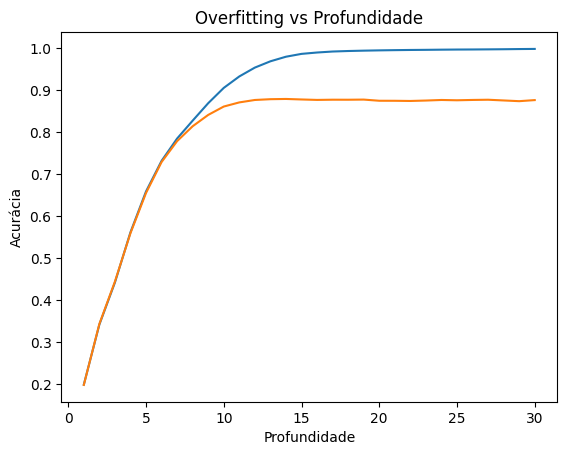

Depth=1 | Train=0.1989 | Test=0.1982
Depth=2 | Train=0.3421 | Test=0.3434
Depth=3 | Train=0.4422 | Test=0.4444
Depth=4 | Train=0.5619 | Test=0.5598
Depth=5 | Train=0.6591 | Test=0.6554
Depth=6 | Train=0.7319 | Test=0.7291
Depth=7 | Train=0.7851 | Test=0.7789
Depth=8 | Train=0.8277 | Test=0.8144
Depth=9 | Train=0.8693 | Test=0.8414
Depth=10 | Train=0.9057 | Test=0.8613
Depth=11 | Train=0.9330 | Test=0.8711
Depth=12 | Train=0.9541 | Test=0.8769
Depth=13 | Train=0.9691 | Test=0.8788
Depth=14 | Train=0.9800 | Test=0.8794
Depth=15 | Train=0.9867 | Test=0.8781
Depth=16 | Train=0.9900 | Test=0.8771
Depth=17 | Train=0.9923 | Test=0.8776
Depth=18 | Train=0.9936 | Test=0.8775
Depth=19 | Train=0.9944 | Test=0.8779
Depth=20 | Train=0.9951 | Test=0.8751
Depth=21 | Train=0.9956 | Test=0.8750
Depth=22 | Train=0.9961 | Test=0.8746
Depth=23 | Train=0.9964 | Test=0.8756
Depth=24 | Train=0.9968 | Test=0.8769
Depth=25 | Train=0.9971 | Test=0.8762
Depth=26 | Train=0.9972 | Test=0.8770
Depth=27 | Train=0.99

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = list(range(1, 31))

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

plt.plot(depths, train_acc)
plt.plot(depths, test_acc)
plt.xlabel("Profundidade")
plt.ylabel("Acurácia")
plt.title("Overfitting vs Profundidade")
plt.show()

for d, tr, te in zip(depths, train_acc, test_acc):
    print(f"Depth={d} | Train={tr:.4f} | Test={te:.4f}")

O gráfico mostra que, à medida que a profundidade da árvore aumenta, a acurácia no conjunto de treino cresce continuamente até atingir valores próximos de 100%.

Por outro lado, a acurácia no conjunto de teste cresce apenas até certo ponto e depois se estabiliza ou começa a diminuir. Esse comportamento indica o início do overfitting.

O overfitting começa aproximadamente na profundidade em que a acurácia de teste deixa de melhorar enquanto a acurácia de treino continua aumentando, criando um gap entre as duas curvas.

Isso ocorre porque o modelo passa a aprender padrões muito específicos e ruídos do conjunto de treino, perdendo capacidade de generalização.

# Questão 5

Execute o pipeline para ambos os modelos:

- Random Forest
- AdaBoost

## Apresente:
- Acurácia, Precisão, Recall e F1-Score de cada modelo

## Responda:
- Qual modelo apresentou melhor desempenho inicial?

**Solução**:

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    return acc, prec, rec, f1


rf_acc, rf_prec, rf_rec, rf_f1 = evaluate_metrics(rf_model, X_test, y_test)
ada_acc, ada_prec, ada_rec, ada_f1 = evaluate_metrics(ada_model, X_test, y_test)

print("Random Forest:")
print("Acurácia:", rf_acc)
print("Precisão:", rf_prec)
print("Recall:", rf_rec)
print("F1-Score:", rf_f1)

print("\nAdaBoost:")
print("Acurácia:", ada_acc)
print("Precisão:", ada_prec)
print("Recall:", ada_rec)
print("F1-Score:", ada_f1)

Random Forest:
Acurácia: 0.9661428571428572
Precisão: 0.966137993950153
Recall: 0.9661428571428572
F1-Score: 0.9661157132080276

AdaBoost:
Acurácia: 0.6681428571428571
Precisão: 0.6883553767508848
Recall: 0.6681428571428571
F1-Score: 0.671134818157636


O modelo Random Forest apresentou melhor desempenho inicial em comparação ao AdaBoost.

Isso ocorre porque o Random Forest combina múltiplas árvores profundas, reduzindo variância e capturando melhor a complexidade dos dados. Já o AdaBoost, por padrão, utiliza modelos mais simples (stumps), o que pode limitar seu desempenho inicial sem ajuste de hiperparâmetros.

Além disso, o Random Forest tende a ser mais robusto a ruídos e overfitting em datasets como o Fashion MNIST.

# Questão 6

Execute o pipeline utilizando diferentes seeds (ex: 42 e 7).

## Analise:
- Os resultados mudaram?

## Responda:
- O experimento é reprodutível? Justifique.

**Solução**:

In [19]:
seeds = [42, 7]

for seed in seeds:
    X_train, X_test, y_train, y_test = load_data(seed)
    
    rf_model = train_random_forest(X_train, y_train, seed)
    ada_model = train_adaboost(X_train, y_train, seed)
    
    rf_acc, rf_prec, rf_rec, rf_f1 = evaluate_metrics(rf_model, X_test, y_test)
    ada_acc, ada_prec, ada_rec, ada_f1 = evaluate_metrics(ada_model, X_test, y_test)
    
    print(f"\nSeed: {seed}")
    
    print("Random Forest:")
    print("Acurácia:", rf_acc)
    print("Precisão:", rf_prec)
    print("Recall:", rf_rec)
    print("F1:", rf_f1)
    
    print("\nAdaBoost:")
    print("Acurácia:", ada_acc)
    print("Precisão:", ada_prec)
    print("Recall:", ada_rec)
    print("F1:", ada_f1)


Seed: 42
Random Forest:
Acurácia: 0.9661428571428572
Precisão: 0.966137993950153
Recall: 0.9661428571428572
F1: 0.9661157132080276

AdaBoost:
Acurácia: 0.6681428571428571
Precisão: 0.6883553767508848
Recall: 0.6681428571428571
F1: 0.671134818157636

Seed: 7
Random Forest:
Acurácia: 0.9682142857142857
Precisão: 0.9682118117569651
Recall: 0.9682142857142857
F1: 0.9681896191190169

AdaBoost:
Acurácia: 0.6115
Precisão: 0.6653145395991795
Recall: 0.6115
F1: 0.6160418891681442


Os resultados apresentam pequenas variações ao utilizar diferentes seeds. Isso ocorre porque a divisão dos dados em treino e teste muda, assim como alguns aspectos internos dos algoritmos que dependem de aleatoriedade.

No entanto, as variações não são significativas, e o comportamento geral dos modelos se mantém consistente.

O experimento é reprodutível, pois ao utilizar a mesma seed, os resultados obtidos são sempre os mesmos. Isso garante que o processo de divisão dos dados e treinamento dos modelos possa ser replicado exatamente, atendendo aos critérios de reprodutibilidade.

# Questão 7

Para pelo menos um dos modelos:

- Compare a acurácia em treino e teste

## Responda:
- Existe overfitting?
- Qual modelo tende a sofrer mais com isso?

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

estimators = [1, 5, 10, 50, 100, 200]

train_acc = []
test_acc = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

for n, tr, te in zip(estimators, train_acc, test_acc):
    print(f"n_estimators={n} | Train={tr:.4f} | Test={te:.4f}")

n_estimators=1 | Train=0.9304 | Test=0.8146
n_estimators=5 | Train=0.9942 | Test=0.9193
n_estimators=10 | Train=0.9992 | Test=0.9462
n_estimators=50 | Train=1.0000 | Test=0.9658
n_estimators=100 | Train=1.0000 | Test=0.9683
n_estimators=200 | Train=1.0000 | Test=0.9694


Ao variar o número de estimadores, observa-se que a acurácia no conjunto de treino tende a ser sempre muito alta, enquanto a acurácia no conjunto de teste melhora até certo ponto e depois se estabiliza.

A diferença entre a acurácia de treino e teste evidencia a presença de overfitting, especialmente quando o modelo apresenta desempenho muito superior no treino em relação ao teste.

Isso mostra que o modelo está aprendendo padrões específicos dos dados de treino que não generalizam bem.

Entre os modelos, árvores de decisão individuais tendem a sofrer mais overfitting, pois conseguem memorizar completamente os dados quando não há restrições. O Random Forest reduz esse problema ao combinar múltiplas árvores, enquanto o AdaBoost pode sofrer overfitting dependendo do número de estimadores e da complexidade do problema.

# Questão 8

Varie pelo menos um hiperparâmetro em cada modelo:

- Random Forest: `n_estimators`
- AdaBoost: `n_estimators`

## Analise:
- O desempenho muda significativamente?

## Responda:
- Qual modelo é mais sensível a mudanças?

In [22]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

rf_estimators = [10, 50, 100, 200]
ada_estimators = [10, 50, 100, 200]

print("Random Forest:")
for n in rf_estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"n_estimators={n} | Acurácia={acc:.4f}")

print("\nAdaBoost:")
for n in ada_estimators:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"n_estimators={n} | Acurácia={acc:.4f}")

Random Forest:
n_estimators=10 | Acurácia=0.9462
n_estimators=50 | Acurácia=0.9658
n_estimators=100 | Acurácia=0.9683
n_estimators=200 | Acurácia=0.9694

AdaBoost:
n_estimators=10 | Acurácia=0.3031
n_estimators=50 | Acurácia=0.6115
n_estimators=100 | Acurácia=0.7177
n_estimators=200 | Acurácia=0.7651


Ao variar o número de estimadores, observa-se que o desempenho do Random Forest melhora inicialmente e depois tende a estabilizar, apresentando pouca variação após certo ponto.

Já o AdaBoost apresenta mudanças mais perceptíveis no desempenho conforme o número de estimadores aumenta, podendo melhorar gradualmente ou até sofrer pequenas oscilações dependendo da configuração.

Isso indica que o AdaBoost é mais sensível a mudanças no hiperparâmetro n_estimators, pois seu funcionamento depende fortemente da combinação sequencial de modelos fracos, onde cada novo estimador influencia diretamente o resultado final.

Por outro lado, o Random Forest tende a ser mais estável, pois os estimadores são treinados de forma independente e a agregação reduz a variabilidade.

# Questão 9

Responda (máx. 2 parágrafos por item):

1. A acurácia é suficiente para avaliar os modelos?
2. Como você garante que o resultado não ocorreu por acaso?
3. Cite dois possíveis problemas metodológicos neste experimento.
4. O pipeline implementado é confiável? Justifique.

1. A acurácia é suficiente para avaliar os modelos?

Não, a acurácia sozinha não é suficiente, pois pode mascarar problemas como desbalanceamento entre classes ou desempenho ruim em classes específicas. Um modelo pode ter alta acurácia geral, mas ainda assim errar muito em determinadas categorias.

Por isso, métricas como precisão, recall e F1-score são importantes, pois fornecem uma visão mais completa do desempenho do modelo em diferentes aspectos, especialmente em cenários com múltiplas classes como o Fashion MNIST.


2. Como você garante que o resultado não ocorreu por acaso?

A utilização de random_state garante que os experimentos sejam reprodutíveis, ou seja, os mesmos resultados podem ser obtidos novamente sob as mesmas condições. Além disso, a análise com diferentes seeds permite verificar a consistência dos resultados.

Outra forma de reduzir o efeito do acaso seria utilizar validação cruzada (cross-validation), que avalia o modelo em múltiplas divisões dos dados, tornando a avaliação mais robusta e confiável.


3. Cite dois possíveis problemas metodológicos neste experimento.

Um possível problema é a utilização de apenas uma divisão treino/teste, o que pode não representar bem o comportamento geral do modelo em diferentes amostras dos dados.

Outro problema é a falta de ajuste fino de hiperparâmetros, o que pode impedir que os modelos atinjam seu melhor desempenho e levar a comparações injustas entre eles.


4. O pipeline implementado é confiável? Justifique.

O pipeline é parcialmente confiável, pois utiliza boas práticas como separação de dados, controle de aleatoriedade e avaliação com múltiplas métricas. Isso garante um nível básico de reprodutibilidade e análise.

No entanto, ele pode ser melhorado com técnicas como validação cruzada, busca de hiperparâmetros e análise mais aprofundada de erros, o que aumentaria ainda mais a confiabilidade dos resultados.